# 511ON Carpool Lots - JSON Map Exploration

**Objective:** Load Ontario carpool lot records from a JSON data link and map each location using latitude and longitude.

**Dataset description:** Each row is one carpool lot location. In this lesson, we keep only `LocationDescription`, `Latitude`, and `Longitude`.

**Data source(s):** https://511on.ca/api/v2/get/carpoollots

**Date/author:** 2026-03-12, Peter (with Codex)


### Step 1: Import libraries
Big picture: load the tools for tables and charts.
Technical details: `pandas` handles DataFrames, and `plotly.express` creates the map chart.


In [9]:
import pandas as pd
import plotly.express as px


### Step 2: Load the JSON data into a DataFrame
Big picture: download the data and view the first few rows.
Technical details: `pd.read_json(...)` reads JSON from the link and builds a table named `df`.


In [10]:
url = "https://511on.ca/api/v2/get/carpoollots"
df = pd.read_json(url)
display(df.head())


,Id,Latitude,Longitude,Highway,LocationDescription,Interchange,EnterLotFrom,ParkingSpaces,AccessibleSpaces,Bike,Lights,Transit,Region
0,128,45.151277,-76.092787,Highway 7,Highway 7 - Cemetery Sideroad / Appleton Sider...,Highway 7,Cemetery Sideroad (Lanark County Road 17),31,4,No,Yes,No,Eastern
1,129,45.200912,-76.035121,Highway 7,Highway 7 - Dwyer Hill Road (Ottawa Road 3),Highway 7,Dwyer Hill Road (Ottawa Road 3),41,3,No,Yes,No,Eastern
2,130,44.316378,-78.198654,Highway 7,Highway 7 - Heritage Line (Peterborough County...,Highway 7,Heritage Line,35,4,No,Yes,No,Eastern
3,131,44.295638,-78.278567,Highway 7,Highway 7 - Keene Road (Peterborough County Ro...,Highway 7,Keene Road,70,6,No,Yes,No,Eastern
4,132,44.267869,-78.349095,Highway 7 / Highway 115,Highway 7 / Highway 115 - The Parkway / Sir Sa...,Highway 7 / Highway 115,Crawford Drive,141,6,No,Yes,Yes,Eastern


### Step 3: Keep only three columns
Big picture: focus only on the map label and coordinates.
Technical details: select `LocationDescription`, `Latitude`, and `Longitude`, then remove rows missing coordinates. In `dropna(subset=["Latitude", "Longitude"])`, `subset` means only these columns are checked for blanks/NaN, and any row with a missing latitude or longitude is dropped.


In [11]:
map_df = df[["LocationDescription", "Latitude", "Longitude"]].copy()
map_df = map_df.dropna(subset=["Latitude", "Longitude"]).copy()
display(map_df.head())


,LocationDescription,Latitude,Longitude
0,Highway 7 - Cemetery Sideroad / Appleton Sider...,45.151277,-76.092787
1,Highway 7 - Dwyer Hill Road (Ottawa Road 3),45.200912,-76.035121
2,Highway 7 - Heritage Line (Peterborough County...,44.316378,-78.198654
3,Highway 7 - Keene Road (Peterborough County Ro...,44.295638,-78.278567
4,Highway 7 / Highway 115 - The Parkway / Sir Sa...,44.267869,-78.349095


### Step 4: Count rows
Big picture: check how many map points we have.
Technical details: `len(map_df)` returns the number of rows in the table.


In [12]:
len(map_df)


120

### Step 5: Plot the map
Big picture: place each location on an interactive map.
Technical details: each row becomes one point; hover text shows `LocationDescription`.


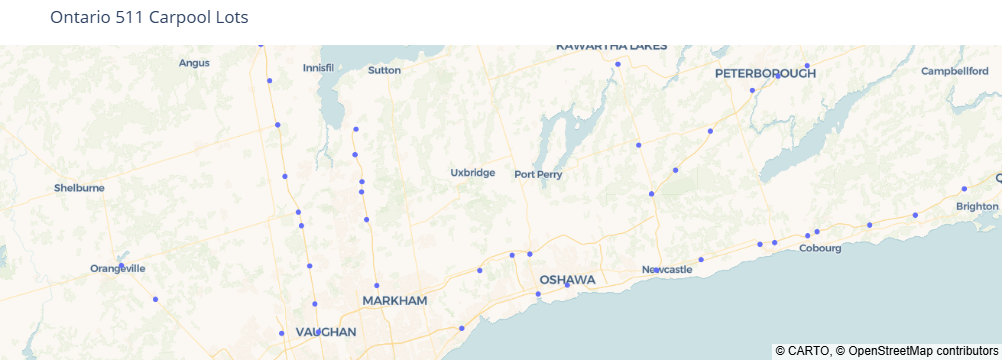

In [26]:
fig = px.scatter_map(
    map_df,
    lat="Latitude",
    lon="Longitude",
    hover_name="LocationDescription",
    zoom=5.3,
    center={"lat": 44.0, "lon": -79.3},
    title="Ontario 511 Carpool Lots",
)

fig.update_layout(map_style="open-street-map")
fig.update_layout(margin={"r": 0, "t": 45, "l": 0, "b": 0})
fig.show()


---
### Open In Colab
[Open this notebook in Google Colab](https://colab.research.google.com/github/pbeens/ICD2O-OSC-2026-Project-Plan-Team-2/blob/main/notebooks/json/511on-carpool-lots-map-exploration.ipynb)
